<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/hinge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


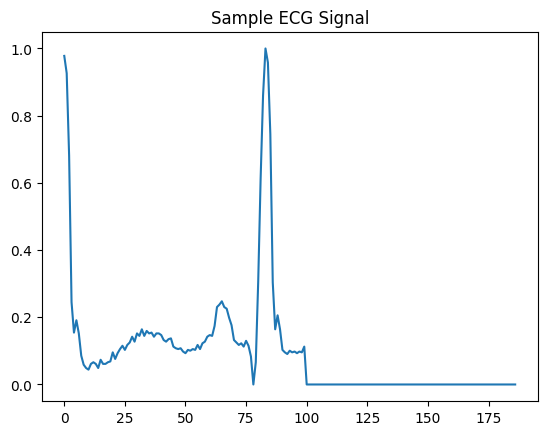

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

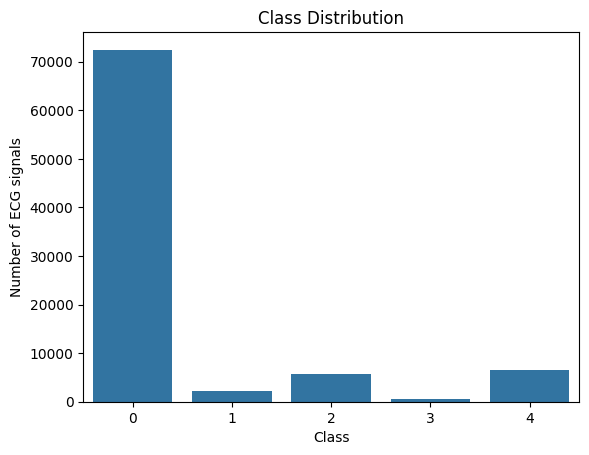

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Convert labels from {0,1} → {-1,1}
y_res_cat = (y_res_cat * 2) - 1
y_test_cat = (y_test_cat * 2) - 1

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [12]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='tanh'))  # needed for hinge loss

    model.compile(
        optimizer='adam',
        loss='hinge',
        metrics=['accuracy']
    )

    return model

In [14]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1

Fold 2

Fold 3

Cross-validation accuracies: [0.9112306833267212, 0.6654799580574036, 0.9537939429283142]
Mean CV accuracy: 0.8435015281041464


In [15]:
model = mobilenet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 474s 103ms/step - accuracy: 0.8439 - loss: 0.1207 - val_accuracy: 0.8397 - val_loss: 0.1304
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 467s 103ms/step - accuracy: 0.9513 - loss: 0.0373 - val_accuracy: 0.9224 - val_loss: 0.0612
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 496s 102ms/step - accuracy: 0.9632 - loss: 0.0274 - val_accuracy: 0.6378 - val_loss: 0.3209
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 456s 101ms/step - accuracy: 0.9764 - loss: 0.0197 - val_accuracy: 0.8247 - val_loss: 0.1399
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 504s 101ms/step - accuracy: 0.9790 - loss: 0.0174 - val_accuracy: 0.9744 - val_loss: 0.0215
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 452s 100ms/step - accuracy: 0.9808 - loss: 0.0161 - val_accuracy: 0.9353 - val_loss: 0.0571
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 446s 98ms/step - accuracy: 0.9812 - loss: 0.0162 - val_accuracy: 0.9660 - val_loss: 0.0325
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 509s 100ms/step - acc

In [16]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax((y_val+1)/2, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step
Validation MCC: 0.9479767425984419


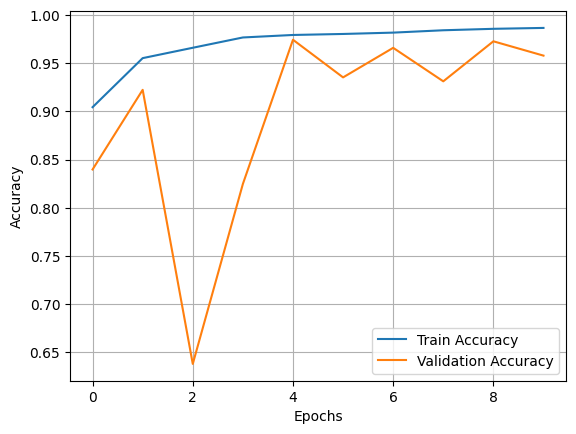

Final Training Accuracy: 0.9867
Final Validation Accuracy: 0.9579


In [17]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Final training & validation loss and accuracy

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]


print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

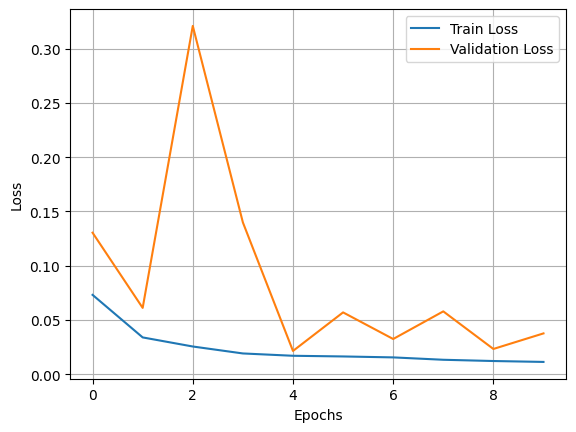

Final Training Loss: 0.0114
Final Validation Loss: 0.0377


In [18]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [19]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.0232
Test Accuracy: 0.9719
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     18118
         1.0       0.66      0.69      0.67       556
         2.0       0.93      0.96      0.94      1448
         3.0       0.82      0.69      0.75       162
         4.0       0.96      0.99      0.98      1608

    accuracy                           0.97     21892
   macro avg       0.87      0.86      0.87     21892
weighted avg       0.97      0.97      0.97     21892



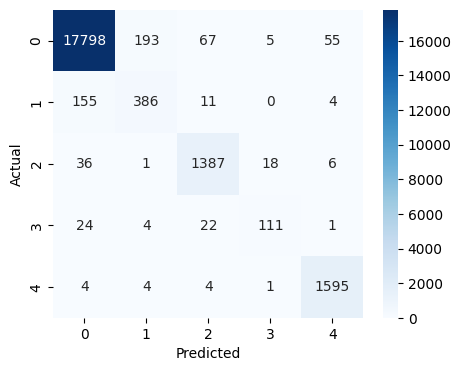

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()